In [3]:
import torch
import numpy as np
from torch.utils.data import DataLoader

from dataloader import KarrDataset, config
from model import ai23

# Inisialisasi Dataset & Dataloader
dataset = KarrDataset()
# Gunakan batch_size kecil dulu untuk debugging, misal 2 atau 4
dataloader = DataLoader(dataset, batch_size=2, shuffle=False, num_workers=4)

# Ambil satu batch pertama
iterator = iter(dataloader)
for i in range(1):
    batch = next(iterator)

print("Berhasil mengambil 1 batch data asli.")
print(f"Batch keys: {batch.keys()}")

Loaded Data Init
Berhasil mengambil 1 batch data asli.
Batch keys: dict_keys(['rgbs', 'segs', 'pcd_xs', 'pcd_zs', 'waypoints', 'rp1', 'rp2', 'velocity'])


In [4]:
# SEL 2: Ekstraksi Tensor Input
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seq_len = config.seq_len
pred_len = config.pred_len

rgbs, segs, pt_cloud_xs, pt_cloud_zs = [], [], [], []
for i in range(seq_len):
    rgbs.append(batch['rgbs'][i].float().to(device))
    segs.append(batch['segs'][i].float().to(device))
    pt_cloud_xs.append(batch['pcd_xs'][i].float().to(device)) 
    pt_cloud_zs.append(batch['pcd_zs'][i].float().to(device))

rp1 = torch.stack(batch['rp1'], dim=1).float().to(device)
rp2 = torch.stack(batch['rp2'], dim=1).float().to(device)
gt_velocity = batch['velocity'].float().to(device)

# Cetak dimensi tensor (Shape)
print(f"Bentuk satu elemen RGB (Frame 0): {rgbs[0].shape} -> Harapan: [B, C, H, W]")
print(f"Bentuk rp1: {rp1.shape} -> Harapan: [B, 2]")
print(f"Bentuk gt_velocity: {gt_velocity.shape} -> Harapan: [B]")

Bentuk satu elemen RGB (Frame 0): torch.Size([2, 3, 256, 512]) -> Harapan: [B, C, H, W]
Bentuk rp1: torch.Size([2, 2]) -> Harapan: [B, 2]
Bentuk gt_velocity: torch.Size([2]) -> Harapan: [B]


In [5]:
# SEL 3: Penyatuan Tensor (Stacking)
import torchvision.transforms as transforms

# Simulasi inisialisasi model
B = rgbs[0].size(0)
S = seq_len
rgb_normalizer = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# Menyatukan List of Tensors menjadi satu Tensor besar
rgbs_stacked = torch.cat(rgbs, dim=0)
pt_cloud_xs_stacked = torch.cat(pt_cloud_xs, dim=0)
pt_cloud_zs_stacked = torch.cat(pt_cloud_zs, dim=0)

in_rgb = rgb_normalizer(rgbs_stacked)

print(f"Bentuk rgbs_stacked: {in_rgb.shape} -> Harapan: [Batch*Seq, C, H, W]")

Bentuk rgbs_stacked: torch.Size([6, 3, 256, 512]) -> Harapan: [Batch*Seq, C, H, W]


In [6]:
# SEL 4: Uji Forward Pass
# Inisialisasi model
model = ai23(config=config, device=device).to(device)
model.eval() # Set ke mode evaluasi untuk debugging (mematikan dropout)

# Eksekusi forward pass
with torch.no_grad(): # Matikan gradien untuk menghemat memori saat debugging
    pred_segs, pred_wp, sdcs = model(rgbs, pt_cloud_xs, pt_cloud_zs, rp1, rp2, gt_velocity)

print("Forward Pass Sukses!")
print(f"Jumlah elemen dalam pred_segs (Harapan = {seq_len}): {len(pred_segs)}")
print(f"Bentuk pred_segs[0]: {pred_segs[0].shape} -> Harapan: [B, num_classes, H, W]")
print(f"Bentuk pred_wp: {pred_wp.shape} -> Harapan: [B, pred_len, 2]")

/home/mf/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mf/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/mf/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Forward Pass Sukses!
Jumlah elemen dalam pred_segs (Harapan = 3): 3
Bentuk pred_segs[0]: torch.Size([2, 20, 256, 512]) -> Harapan: [B, num_classes, H, W]
Bentuk pred_wp: torch.Size([2, 3, 2]) -> Harapan: [B, pred_len, 2]


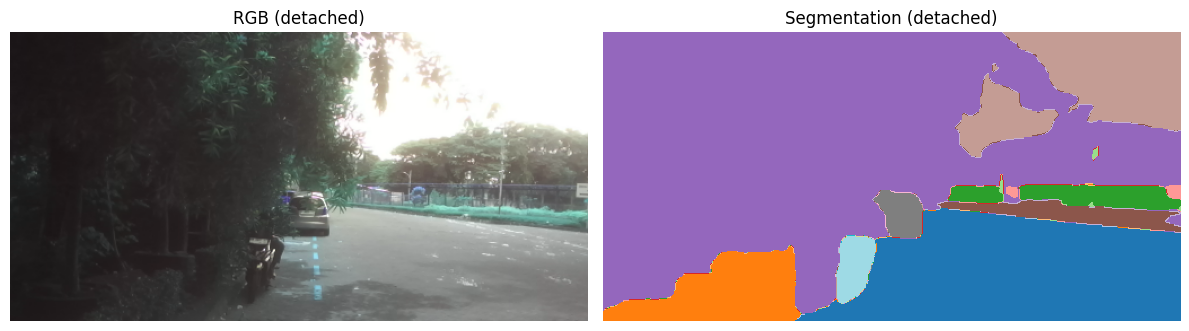

In [7]:
# SEL 5: Visualisasi RGB dan Segmentation setelah detach()
import matplotlib.pyplot as plt

# Ambil frame pertama dari sequence dan sample pertama dari batch
rgb_tensor = rgbs[0][0].detach().cpu()
seg_tensor = segs[0][0].detach().cpu()

# [C, H, W] -> [H, W, C] untuk ditampilkan
rgb_img = rgb_tensor.permute(1, 2, 0).numpy()

# Tangani berbagai format seg tensor
if seg_tensor.ndim == 3:
    # Jika multi-channel, ambil kelas via argmax; jika single-channel, squeeze
    seg_img = seg_tensor.argmax(dim=0).numpy() if seg_tensor.shape[0] > 1 else seg_tensor.squeeze(0).numpy()
elif seg_tensor.ndim == 2:
    seg_img = seg_tensor.numpy()
else:
    raise ValueError(f"Format seg tidak dikenali: {seg_tensor.shape}")

# Normalisasi sederhana jika RGB masih skala 0-255
if rgb_img.max() > 1.0:
    rgb_img = rgb_img / 255.0

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title("RGB (detached)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(seg_img, cmap="tab20")
plt.title("Segmentation (detached)")
plt.axis("off")

plt.tight_layout()
plt.show()

3


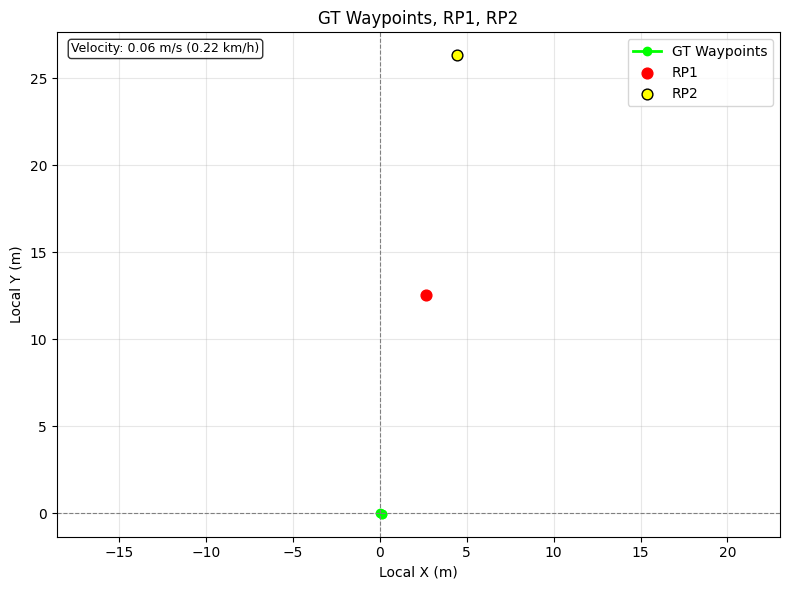

Velocity: 0.060 m/s (0.216 km/h)
Projection area (meter):
  left-right: [-24.00, 24.00]
  forward   : [2.00, 40.00]
GT waypoint local (m):
[[-0.00106515  0.00093102]
 [ 0.14810082 -0.0411541 ]
 [ 0.1478576  -0.04276241]]
GT in-view:
[False False False]
RP1 local (m):
[ 2.6836174 12.523983 ]
RP1 in-view:
True
RP2 local (m):
[ 4.4566627 26.329876 ]
RP2 in-view:
True


In [8]:
# SEL 6: Plot GT waypoint, RP1, dan RP2 dengan matplotlib biasa
import numpy as np
import matplotlib.pyplot as plt
from dataset_processing.config import GlobalConfig as PlotConfig

plot_config = PlotConfig()
sample_idx = 0

# Default PyTorch collation menyimpan setiap waypoint sebagai pasangan tensor per-koordinat.
# Rekonstruksi satu sample menjadi array [pred_len, 2] agar titik yang diplot benar.
wp_gt_local_list = []
print(len(batch['waypoints']))
for j in range(len(batch['waypoints'])):
    x = batch['waypoints'][j][0][sample_idx].detach().cpu().item()
    y = batch['waypoints'][j][1][sample_idx].detach().cpu().item()
    wp_gt_local_list.append([x, y])

wp_gt_local = np.stack(wp_gt_local_list, axis=0)

rp1_local = rp1[sample_idx].detach().cpu().numpy()
rp2_local = rp2[sample_idx].detach().cpu().numpy()
velocity_ms = gt_velocity[sample_idx].detach().cpu().item()
velocity_kmh = velocity_ms * 3.6
lr_min, lr_max = plot_config.cam_cover_area_lr
rf_min, rf_max = plot_config.cam_cover_area_rf

gt_in_view = ((wp_gt_local[:, 0] >= lr_min) & (wp_gt_local[:, 0] <= lr_max) & (wp_gt_local[:, 1] >= rf_min) & (wp_gt_local[:, 1] <= rf_max))
rp1_in_view = ((rp1_local[0] >= lr_min) & (rp1_local[0] <= lr_max) & (rp1_local[1] >= rf_min) & (rp1_local[1] <= rf_max))
rp2_in_view = ((rp2_local[0] >= lr_min) & (rp2_local[0] <= lr_max) & (rp2_local[1] >= rf_min) & (rp2_local[1] <= rf_max))

plt.figure(figsize=(8, 6))
plt.plot(wp_gt_local[:, 0], wp_gt_local[:, 1], '-o', color='lime', linewidth=2, markersize=6, label='GT Waypoints')
plt.scatter([rp1_local[0]], [rp1_local[1]], color='red', s=60, label='RP1', zorder=3)
plt.scatter([rp2_local[0]], [rp2_local[1]], color='yellow', s=60, label='RP2', edgecolors='black', zorder=3)
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.xlabel('Local X (m)')
plt.ylabel('Local Y (m)')
plt.title('GT Waypoints, RP1, RP2')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend(loc='best')
plt.text(0.02, 0.98, f'Velocity: {velocity_ms:.2f} m/s ({velocity_kmh:.2f} km/h)', transform=plt.gca().transAxes, va='top', ha='left', fontsize=9, bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

print(f'Velocity: {velocity_ms:.3f} m/s ({velocity_kmh:.3f} km/h)')
print('Projection area (meter):')
print(f'  left-right: [{lr_min:.2f}, {lr_max:.2f}]')
print(f'  forward   : [{rf_min:.2f}, {rf_max:.2f}]')

print('GT waypoint local (m):')
print(wp_gt_local)
print('GT in-view:')
print(gt_in_view)

print('RP1 local (m):')
print(rp1_local)
print('RP1 in-view:')
print(rp1_in_view)

print('RP2 local (m):')
print(rp2_local)
print('RP2 in-view:')
print(rp2_in_view)